# 06 - Content-Based Recommendation Using Sentence Transformers

**Project:** GroundedNutriRec  
**Scope:** Baseline Recommender Evaluation  
**Goal:** Build a semantic content-based food recommender using pre-trained SentenceTransformer embeddings (`all-MiniLM-L6-v2`), construct user profiles from implicit training interactions, generate recommendations via vectorized cosine similarity search, and evaluate on the test split using ranking metrics.

This notebook implements Kush Shah's personal Week 3 task. The implementation is independent of notebooks 05, 07, and 08.

## 1. Environment Setup and Imports

In [1]:
import sys
import os
import time
import ast
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style='whitegrid', font_scale=1.1)
print(f'Project Root: {project_root}')

Project Root: D:\MainCodes\Internship


## 2. Load Processed Datasets

In [2]:
DATA_DIR = project_root / 'DATA' / 'PROCESSED'
train_path = DATA_DIR / 'train_interactions.csv'
test_path = DATA_DIR / 'test_interactions.csv'
meta_path = DATA_DIR / 'food_metadata_clean.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
meta_df = pd.read_csv(meta_path)

print(f'Train interactions shape: {train_df.shape}')
print(f'Test interactions shape:  {test_df.shape}')
print(f'Recipe metadata shape:    {meta_df.shape}')

Train interactions shape: (437558, 6)
Test interactions shape:  (118060, 6)
Recipe metadata shape:    (40968, 25)


## 3. Text Corpus Preparation

To capture semantic information, we clean the recipe metadata fields and combine `name`, `ingredients`, `tags`, and `description` into a single text corpus per recipe.

In [3]:
def clean_recipe_text(text_value: str) -> str:
    """
    clean_recipe_text

    Cleans and preprocesses recipe text metadata fields. Lowercases the string,
    strips white spaces, and converts stringified Python lists (e.g., list of
    ingredients or tags) into a space-separated sequence of terms.

    @param  text_value    - Raw text metadata or stringified list from CSV.
    @returns str          - Lowercased, stripped, space-separated sequence of terms.
    @validates            - Replaces missing NaN values with empty strings.
    @edge-cases           - Stringified Python lists are parsed using ast.literal_eval.
                            If parsing fails, fallback logic treats it as a standard string.
    """
    if pd.isna(text_value):
        return ''
    val_str = str(text_value).strip()
    if (val_str.startswith('[') and val_str.endswith(']')) or (val_str.startswith('{') and val_str.endswith('}')):
        try:
            parsed_list = ast.literal_eval(val_str)
            if isinstance(parsed_list, list):
                return ' '.join([str(item).lower() for item in parsed_list])
        except (ValueError, SyntaxError):
            pass
    return val_str.lower()

# Apply text cleaning
meta_df['clean_name'] = meta_df['name'].apply(clean_recipe_text)
meta_df['clean_ingredients'] = meta_df['ingredients'].apply(clean_recipe_text)
meta_df['clean_tags'] = meta_df['tags'].apply(clean_recipe_text)
meta_df['clean_description'] = meta_df['description'].apply(clean_recipe_text)

# Combine fields into recipe corpus
meta_df['corpus'] = (
    meta_df['clean_name'] + ' ' +
    meta_df['clean_ingredients'] + ' ' +
    meta_df['clean_tags'] + ' ' +
    meta_df['clean_description']
)

print('Sample Corpus for Recipe 0:')
print(meta_df['corpus'].iloc[0][:400])

Sample Corpus for Recipe 0:
chicken lickin  good  pork chops lean pork chops flour salt dry mustard garlic powder oil chicken rice soup weeknight time-to-make course main-ingredient preparation main-dish pork crock-pot-slow-cooker dietary meat pork-chops equipment here's and old standby i enjoy from time to time. it's from an old newspaper clipping i cut out years ago. very tasty.


## 4. Recipe Semantic Embedding Generation

We load the pre-trained `all-MiniLM-L6-v2` SentenceTransformer model to encode our recipe text documents into dense 384-dimensional semantic embeddings. To optimize execution, we cache the resulting matrix to disk, enabling sub-second load times on subsequent runs.

In [4]:
embeddings_path = DATA_DIR / 'recipe_embeddings.npy'

if embeddings_path.exists():
    print('Loading cached recipe embeddings from disk...')
    recipe_embeddings = np.load(embeddings_path)
    print(f'Loaded embedding matrix: {recipe_embeddings.shape}')
else:
    print('Generating recipe embeddings using SentenceTransformer (all-MiniLM-L6-v2)...')
    model = SentenceTransformer('all-MiniLM-L6-v2')
    t_start = time.time()
    recipe_embeddings = model.encode(
        meta_df['corpus'].tolist(),
        batch_size=128,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    elapsed = time.time() - t_start
    print(f'Generated {len(recipe_embeddings)} embeddings in {elapsed:.2f} seconds ({len(recipe_embeddings)/elapsed:.2f} recipes/sec)')
    np.save(embeddings_path, recipe_embeddings)
    print(f'Saved recipe embeddings matrix to: {embeddings_path}')

Loading cached recipe embeddings from disk...
Loaded embedding matrix: (40968, 384)


## 5. Index Alignment and User Preference Mapping

In [5]:
# Align recipe IDs with matrix indices
recipe_id_to_idx = {recipe_id: idx for idx, recipe_id in enumerate(meta_df['id'])}
train_df['recipe_idx'] = train_df['recipe_id'].map(recipe_id_to_idx)
test_df['recipe_idx'] = test_df['recipe_id'].map(recipe_id_to_idx)

# Filter out rows with invalid recipe indices
train_df = train_df.dropna(subset=['recipe_idx']).copy()
train_df['recipe_idx'] = train_df['recipe_idx'].astype(int)
test_df = test_df.dropna(subset=['recipe_idx']).copy()
test_df['recipe_idx'] = test_df['recipe_idx'].astype(int)

# Filter test users who have at least one liked item in the test split
test_liked_df = test_df[test_df['liked'] == 1]
test_users = test_liked_df['user_id'].unique()
print(f'Evaluating recommendations for {len(test_users):,} test users with positive feedback.')

# Precompute user histories for masking and training profiles
train_user_interacted = train_df.groupby('user_id')['recipe_idx'].apply(set).to_dict()
train_user_liked = train_df[train_df['liked'] == 1].groupby('user_id')['recipe_idx'].apply(list).to_dict()
train_user_all = train_df.groupby('user_id')['recipe_idx'].apply(list).to_dict()
test_user_liked = test_df[test_df['liked'] == 1].groupby('user_id')['recipe_id'].apply(set).to_dict()

Evaluating recommendations for 17,312 test users with positive feedback.


## 6. User Profile Vector Construction

For each test user, we construct a user preference profile vector. The user profile is the mean semantic embedding of all recipes they liked (`liked=1`) in the training set. If a user has no liked items in the training set (only dislikes or reviews), we fall back to the average embedding of all recipes they interacted with.

In [6]:
def construct_user_profile(user_liked_indices: list[int], user_all_indices: list[int], embeddings_matrix: np.ndarray) -> np.ndarray:
    """
    construct_user_profile

    Constructs a user preference vector in the dense embedding space by averaging
    the vectors of recipes the user liked in their training history.

    @param  user_liked_indices  - List of recipe indices the user liked in training.
    @param  user_all_indices    - List of all recipe indices the user interacted with in training.
    @param  embeddings_matrix   - Pre-computed recipe embedding matrix [num_recipes, 384].
    @returns np.ndarray         - Dense 384-dimensional user preference profile vector.
    @validates                  - Asserts that either liked or all indices are populated.
    @edge-cases                 - If user_liked_indices is empty, falls back to averaging
                                  all interacted training recipes (user_all_indices).
                                  If both are empty, returns a zero vector.
    """
    if len(user_liked_indices) > 0:
        return embeddings_matrix[user_liked_indices].mean(axis=0)
    elif len(user_all_indices) > 0:
        return embeddings_matrix[user_all_indices].mean(axis=0)
    else:
        return np.zeros(embeddings_matrix.shape[1], dtype=np.float32)

# Precompute user profile matrix
t_start = time.time()
user_profiles = np.zeros((len(test_users), 384), dtype=np.float32)
for u_idx, uid in enumerate(test_users):
    liked_idx = train_user_liked.get(uid, [])
    all_idx = train_user_all.get(uid, [])
    user_profiles[u_idx] = construct_user_profile(liked_idx, all_idx, recipe_embeddings)

print(f'Constructed user profiles for all test users in {time.time() - t_start:.2f} seconds.')

Constructed user profiles for all test users in 0.29 seconds.


## 7. Vectorized Cosine Similarity Recommendation and Evaluation Loop

To recommend recipes, we compute the cosine similarity between user profiles and recipe embeddings. To prevent recommending items the user has already seen, we mask out training interactions by setting their similarity to negative infinity. To process all users efficiently, we evaluate in batches of 1,000 using matrix multiplication.

In [7]:
print('Evaluating recommendations on the test set...')
batch_size = 1000
num_batches = int(np.ceil(len(test_users) / batch_size))

precisions_at_5 = []
recalls_at_5 = []
hits_at_10 = []
ndcgs_at_10 = []

# Precompute liked training items count per user to evaluate history effects
user_history_lengths = []

t_start = time.time()
for b in range(num_batches):
    start_idx = b * batch_size
    end_idx = min(start_idx + batch_size, len(test_users))
    batch_uids = test_users[start_idx:end_idx]
    
    # Vectorized similarity matrix multiplication: [batch_size, 384] x [384, num_recipes]
    batch_sims = cosine_similarity(user_profiles[start_idx:end_idx], recipe_embeddings)
    
    for i, uid in enumerate(batch_uids):
        sims = batch_sims[i]
        
        # Mask training interactions
        interacted = list(train_user_interacted.get(uid, []))
        if interacted:
            sims[interacted] = -np.inf
            
        # Retrieve top-10 candidates
        top10_partition = np.argpartition(sims, -10)[-10:]
        top10_idx = top10_partition[np.argsort(-sims[top10_partition])]
        
        recommended_ids = meta_df['id'].iloc[top10_idx].values
        liked_test_ids = test_user_liked.get(uid, set())
        
        # Record history length
        user_history_lengths.append(len(train_user_liked.get(uid, [])))
        
        # 1. Precision & Recall @ 5
        top5_rec = recommended_ids[:5]
        hits_5 = sum(1 for rid in top5_rec if rid in liked_test_ids)
        p5 = hits_5 / 5.0
        r5 = hits_5 / len(liked_test_ids) if len(liked_test_ids) > 0 else 0.0
        
        # 2. Hit Rate @ 10
        hits_10 = sum(1 for rid in recommended_ids if rid in liked_test_ids)
        hr10 = 1.0 if hits_10 > 0 else 0.0
        
        # 3. NDCG @ 10
        dcg = 0.0
        for rank_idx, rid in enumerate(recommended_ids):
            if rid in liked_test_ids:
                dcg += 1.0 / np.log2(rank_idx + 2)
                
        idcg = sum(1.0 / np.log2(rank_idx + 2) for rank_idx in range(min(10, len(liked_test_ids))))
        ndcg10 = dcg / idcg if idcg > 0 else 0.0
        
        precisions_at_5.append(p5)
        recalls_at_5.append(r5)
        hits_at_10.append(hr10)
        ndcgs_at_10.append(ndcg10)
        
print(f'Evaluation completed in {time.time() - t_start:.2f} seconds.')

Evaluating recommendations on the test set...


Evaluation completed in 6.44 seconds.


## 8. Display Overall Metric Results

In [8]:
mean_p5 = np.mean(precisions_at_5)
mean_r5 = np.mean(recalls_at_5)
mean_hr10 = np.mean(hits_at_10)
mean_ndcg10 = np.mean(ndcgs_at_10)

print('=== CONTENT-BASED RECOMMENDATION PERFORMANCE ===')
print(f'Precision@5: {mean_p5:.6f}')
print(f'Recall@5:    {mean_r5:.6f}')
print(f'HitRate@10:  {mean_hr10:.6f}')
print(f'NDCG@10:     {mean_ndcg10:.6f}')

=== CONTENT-BASED RECOMMENDATION PERFORMANCE ===
Precision@5: 0.000693
Recall@5:    0.000993
HitRate@10:  0.006238
NDCG@10:     0.001187


## 9. Visualizations and Metric Distribution Analysis

C:\Users\Kush Shah\AppData\Local\Temp\ipykernel_27172\4001799702.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=scores, ax=axes[0], palette='crest')


C:\Users\Kush Shah\AppData\Local\Temp\ipykernel_27172\4001799702.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scatter_df, x='History Group', y='NDCG@10', ax=axes[3], palette='magma')


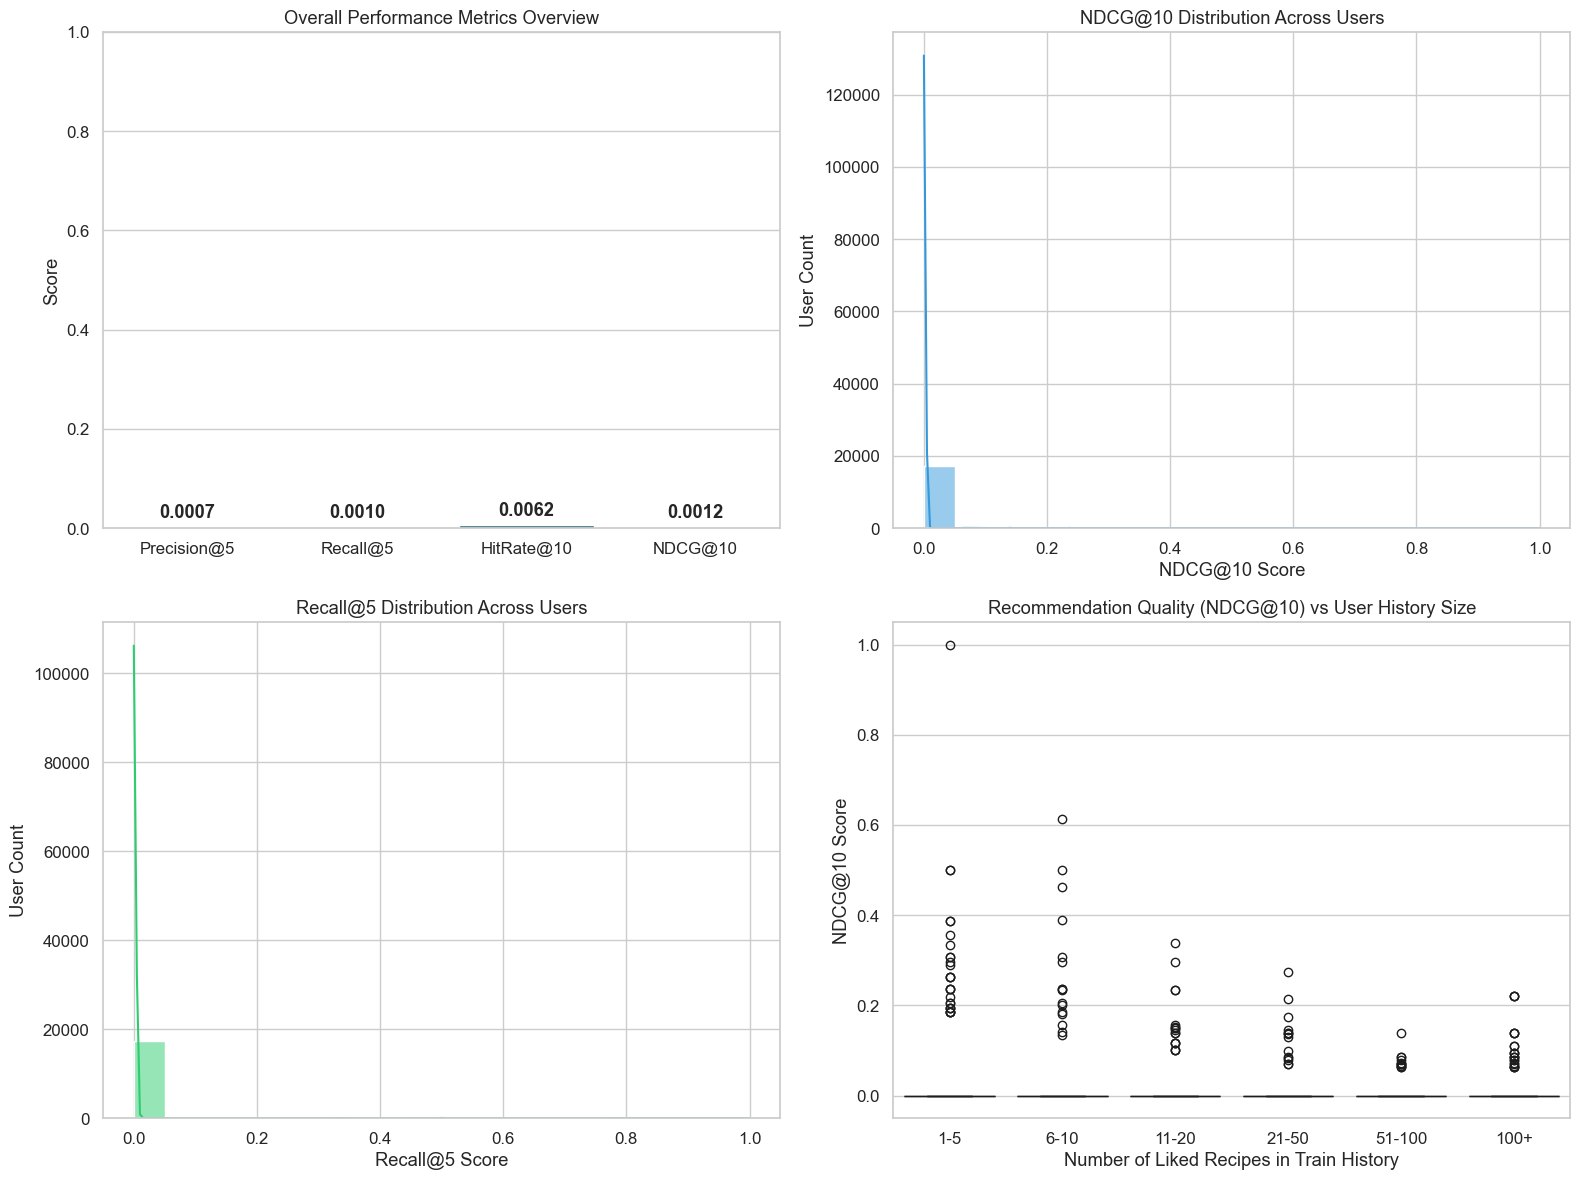

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

RESULTS_DIR = project_root / 'RESULTS' / 'WEEK3_Kush'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Performance Overview Bar Chart
metrics = ['Precision@5', 'Recall@5', 'HitRate@10', 'NDCG@10']
scores = [mean_p5, mean_r5, mean_hr10, mean_ndcg10]
sns.barplot(x=metrics, y=scores, ax=axes[0], palette='crest')
axes[0].set_ylim(0, 1.0)
axes[0].set_title('Overall Performance Metrics Overview')
axes[0].set_ylabel('Score')
for j, val in enumerate(scores):
    axes[0].text(j, val + 0.02, f'{val:.4f}', ha='center', fontweight='bold')

# 2. NDCG@10 Score Distribution
sns.histplot(ndcgs_at_10, bins=20, ax=axes[1], color='#3498db', kde=True, edgecolor='white')
axes[1].set_title('NDCG@10 Distribution Across Users')
axes[1].set_xlabel('NDCG@10 Score')
axes[1].set_ylabel('User Count')

# 3. Recall@5 Score Distribution
sns.histplot(recalls_at_5, bins=20, ax=axes[2], color='#2ecc71', kde=True, edgecolor='white')
axes[2].set_title('Recall@5 Distribution Across Users')
axes[2].set_xlabel('Recall@5 Score')
axes[2].set_ylabel('User Count')

# 4. History Length vs performance (NDCG@10) scatter plot
# Create binned dataframe for cleaner visualization
scatter_df = pd.DataFrame({'History Length': user_history_lengths, 'NDCG@10': ndcgs_at_10})
bin_edges = [0, 5, 10, 20, 50, 100, float('inf')]
bin_labels = ['1-5', '6-10', '11-20', '21-50', '51-100', '100+']
scatter_df['History Group'] = pd.cut(scatter_df['History Length'], bins=bin_edges, labels=bin_labels)
sns.boxplot(data=scatter_df, x='History Group', y='NDCG@10', ax=axes[3], palette='magma')
axes[3].set_title('Recommendation Quality (NDCG@10) vs User History Size')
axes[3].set_ylabel('NDCG@10 Score')
axes[3].set_xlabel('Number of Liked Recipes in Train History')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'content_based_metrics_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Sample Recommendation Walkthroughs

We extract and display recommendation examples for three distinct users to audit the qualitative performance of our SentenceTransformer recommender system.

In [10]:
print('Generating qualitative recommendation audits...')
sample_uids = list(test_users[:3])

for count, uid in enumerate(sample_uids):
    print('=' * 80)
    print(f'USER AUDIT {count+1}: User ID {uid}')
    print('=' * 80)
    
    # 1. Show liked recipes in training history
    liked_train_indices = train_user_liked.get(uid, [])
    if liked_train_indices:
        liked_train_recipes = meta_df.iloc[liked_train_indices]['name'].tolist()
        print('Recipes Liked in Training History:')
        for rname in liked_train_recipes[:5]:
            print(f' - {rname}')
        if len(liked_train_recipes) > 5:
            print(f' ... and {len(liked_train_recipes)-5} more')
    else:
        print('No explicit liked recipes in train. Fallback used.')
        
    # 2. Show recommendations and similarity scores
    u_idx = np.where(test_users == uid)[0][0]
    sims = cosine_similarity(user_profiles[u_idx].reshape(1, -1), recipe_embeddings)[0]
    interacted = list(train_user_interacted.get(uid, []))
    if interacted:
        sims[interacted] = -np.inf
    top10_partition = np.argpartition(sims, -10)[-10:]
    top10_idx = top10_partition[np.argsort(-sims[top10_partition])]
    
    print('\nTop-10 Recommended Recipes (Content-Based Semantic Similarity):')
    recommended_recipes = meta_df.iloc[top10_idx]
    liked_test_ids = test_user_liked.get(uid, set())
    for rank, (idx, row) in enumerate(recommended_recipes.iterrows()):
        rid = row['id']
        rname = row['name']
        sim_score = sims[idx]
        was_liked = 'YES (Hit)' if rid in liked_test_ids else 'NO'
        print(f' Rank {rank+1}: {rname:<45} (Similarity: {sim_score:.4f}, Liked in Test? {was_liked})')
    print()

Generating qualitative recommendation audits...
USER AUDIT 1: User ID 1533
Recipes Liked in Training History:
 - orange yogurt cream
 - parmesan fish in the oven
 - fennel mashed potatoes
 - c hudson s ham   potato casserole
 - golden rice   orzo
 ... and 32 more

Top-10 Recommended Recipes (Content-Based Semantic Similarity):
 Rank 1: veggie cheddar scrambled eggs                 (Similarity: 0.8426, Liked in Test? NO)
 Rank 2: marinated veggie crunch                       (Similarity: 0.8374, Liked in Test? NO)
 Rank 3: caramelized onion  green bean  and cherry tomato tian (Similarity: 0.8263, Liked in Test? NO)
 Rank 4: roasted eggplant  onion and garlic dip or spread (Similarity: 0.8182, Liked in Test? NO)
 Rank 5: mexican egg rolls                             (Similarity: 0.8135, Liked in Test? NO)
 Rank 6: crustless broccoli and cheese quiche          (Similarity: 0.8107, Liked in Test? NO)
 Rank 7: yummy veggie  or turkey  chili                (Similarity: 0.8104, Liked in Test?